
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [15]:
import pandas as pd
medical_df = pd.read_csv('/Users/myroslavazuieva/Desktop/ML/medical-charges.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Для прогнозування значення charges можна:

1.	Згрупувати дані за категоріями (smoker, sex, region) і розрахувати середнє/медіану для кожної групи.
  
2.	Вивчити кореляцію між числовими змінними (age, bmi, children) і charges, щоб виявити сильні залежності.

3.	Використати візуалізацію, щоб знайти взаємозв’язки і закономірності в даних.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

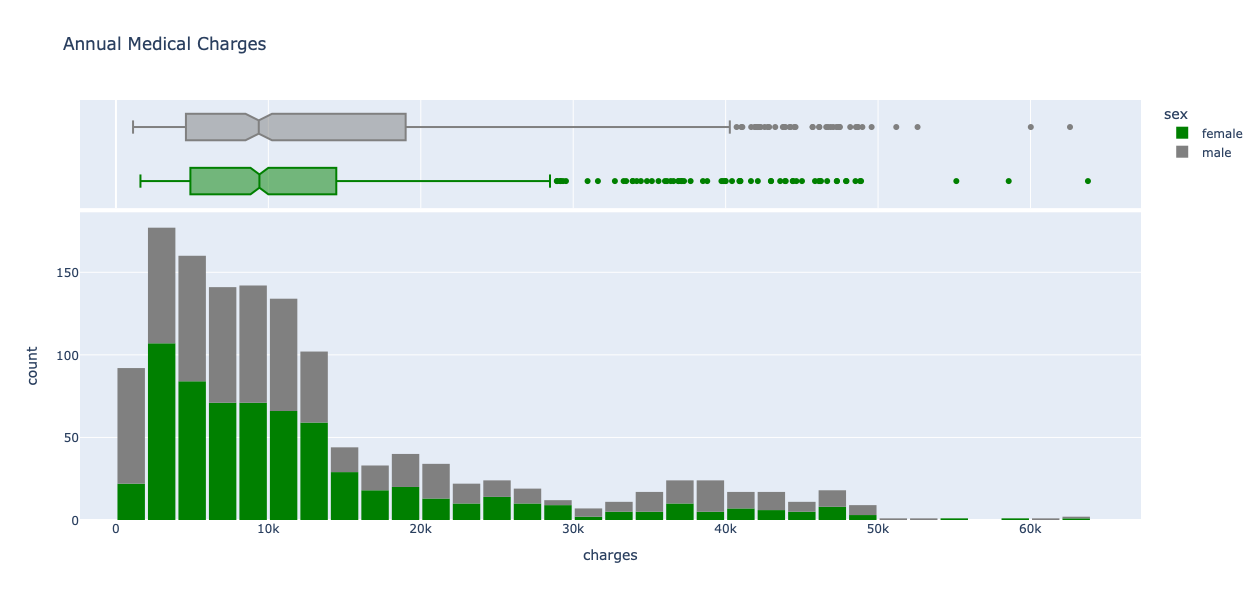

In [30]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(
    bargap=0.1,
    width=1200,
    height=600
)
fig.show()

1. У чоловіків більше дуже високих charges:
- На бокс-плоті видно, що чоловіки має довші “вуса” вправо — більше аутлаєрів з витратами > 30 000.
- Це може вказувати, що чоловіки частіше мають дорогі страхові випадки.

2. Жінки мають трохи менші середні charges.

3. Обидва розподіли мають більшість charges у вигляді невеликих сум, але є кілька дуже великих значень аутлаєрів.

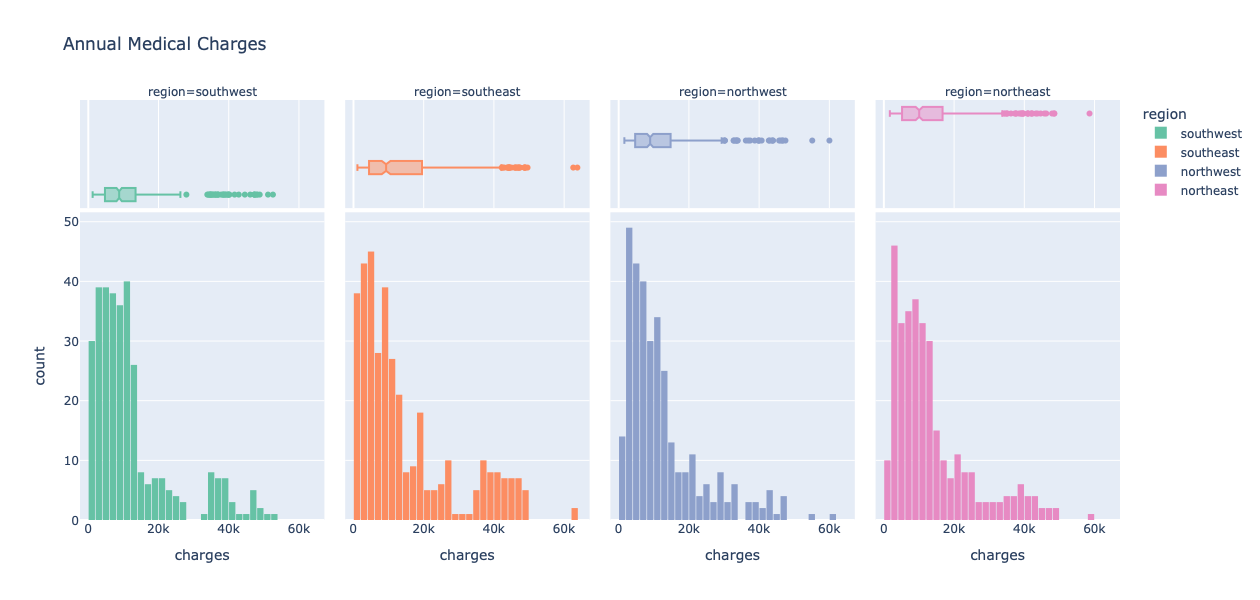

In [32]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   facet_col='region',
                   color_discrete_sequence=px.colors.qualitative.Set2,
                   title='Annual Medical Charges')
fig.update_layout(
    bargap=0.1,
    width=1200,
    height=600
)
fig.show()

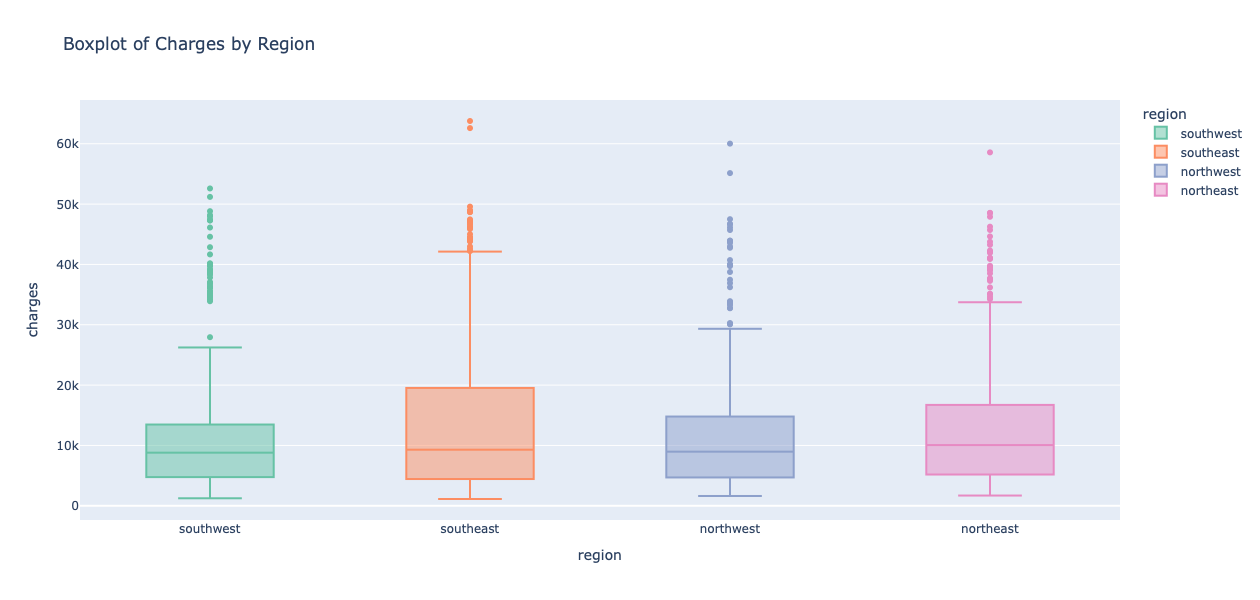

In [33]:
fig = px.box(medical_df, 
             x='region', 
             y='charges', 
             color='region',
             color_discrete_sequence=px.colors.qualitative.Set2,
             title='Boxplot of Charges by Region')
fig.update_layout(
    bargap=0.1,
    width=1200,
    height=600
)
fig.show()

1.	Найбільші charges спостерігаються в регіоні northeast.
- Медіана витрат там найвища.
- Багато пацієнтів мають витрати понад 25 000–30 000, що видно як викиди на боксплоті.
- Це може свідчити про дорожчу медицину, старшу популяцію або більшу частку хворих.

2.	Найнижчі charges — у southeast:
- Медіана — найменша серед усіх регіонів.
- Більшість витрат не перевищують 10 000–12 000.
- Ймовірно, населення молодше або має менше медичних потреб.
  
3.	Регіони southwest та northwest — проміжні:
- У northwest витрати вищі за середні, є викиди.
- У southwest більшість витрат також зосереджена на нижчих значеннях, але з деякими дорогими випадками.

Регіон впливає на рівень цін на медичне страхування:
- Розподіли витрат значно відрізняються між регіонами.
- Візуально видно, що медіани, розмах, кількість дорогих страхувань і загальний розподіл суттєво змінюються залежно від регіону.
- Це означає, що географічне розташування є важливим фактором, який варто враховувати при аналізі витрат на медицину.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

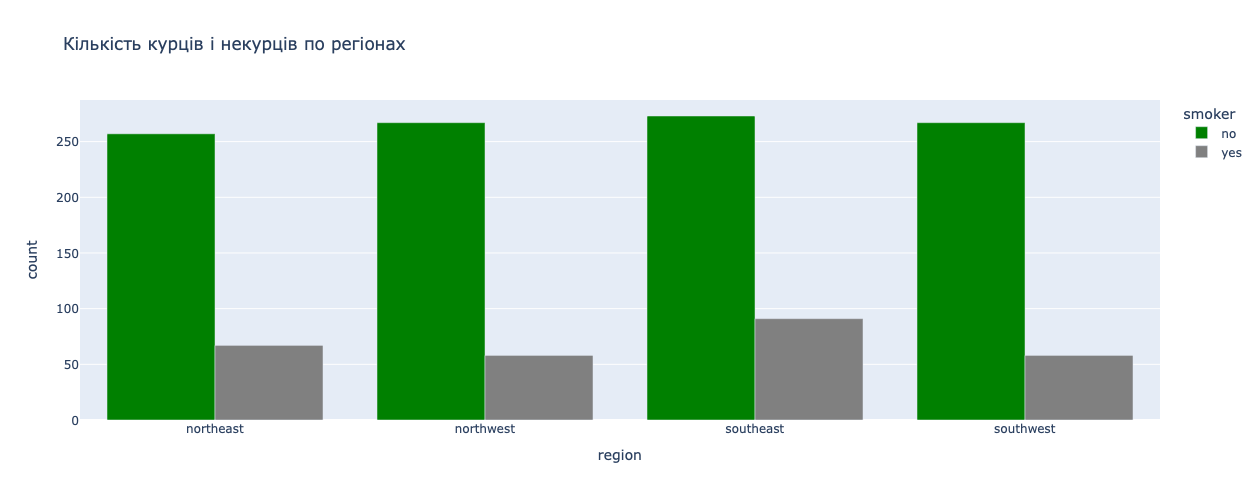

In [38]:
region_counts = (medical_df
                 .groupby(['region', 'smoker'])
                 .size()
                 .reset_index(name='count'))

fig = px.bar(region_counts, 
             x='region', 
             y='count', 
             color='smoker', 
             barmode='group',
             title='Кількість курців і некурців по регіонах',
             color_discrete_sequence=['green', 'grey'])

fig.update_layout(width=1000, height=500)
fig.show()

- У регіоні southeast — найбільше курців.
- У регіоні northwest та southwest — курців найменше.
- Це може вказувати на регіональні відмінності в поведінці та здоров’ї населення.

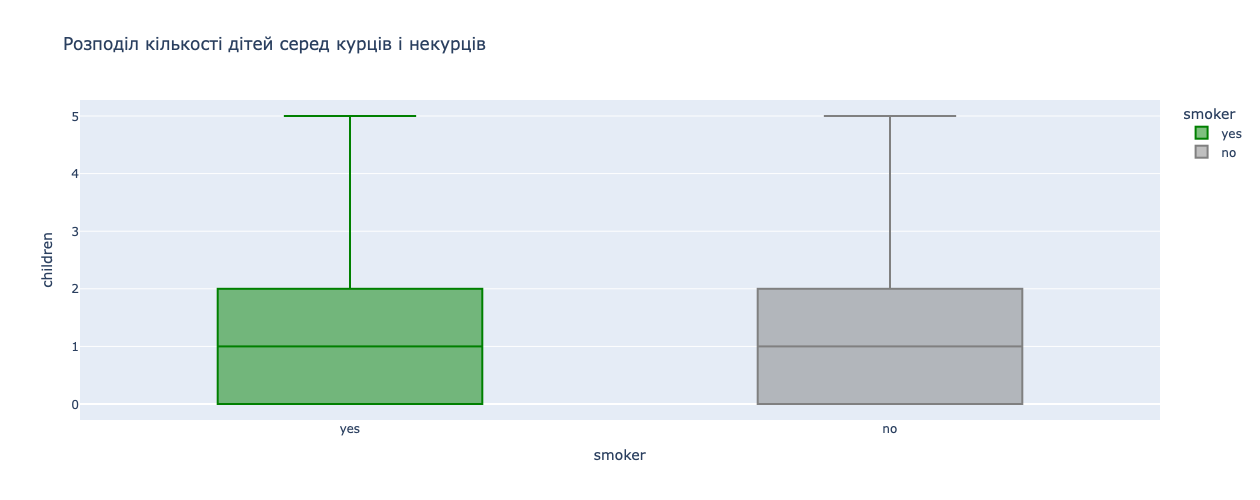

In [39]:
fig = px.box(medical_df,
             x='smoker',
             y='children',
             title='Розподіл кількості дітей серед курців і некурців',
             color='smoker',
             color_discrete_sequence=['green', 'grey'])
fig.update_layout(width=700, height=500)
fig.show()

- Курці мають приблизно таку ж кількість дітей, як і некурці.
- Найбільше людей у обох груп мають 0–2 дітей.
- Візуально немає суттєвої різниці між групами — куріння не корелює сильно з кількістю дітей.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

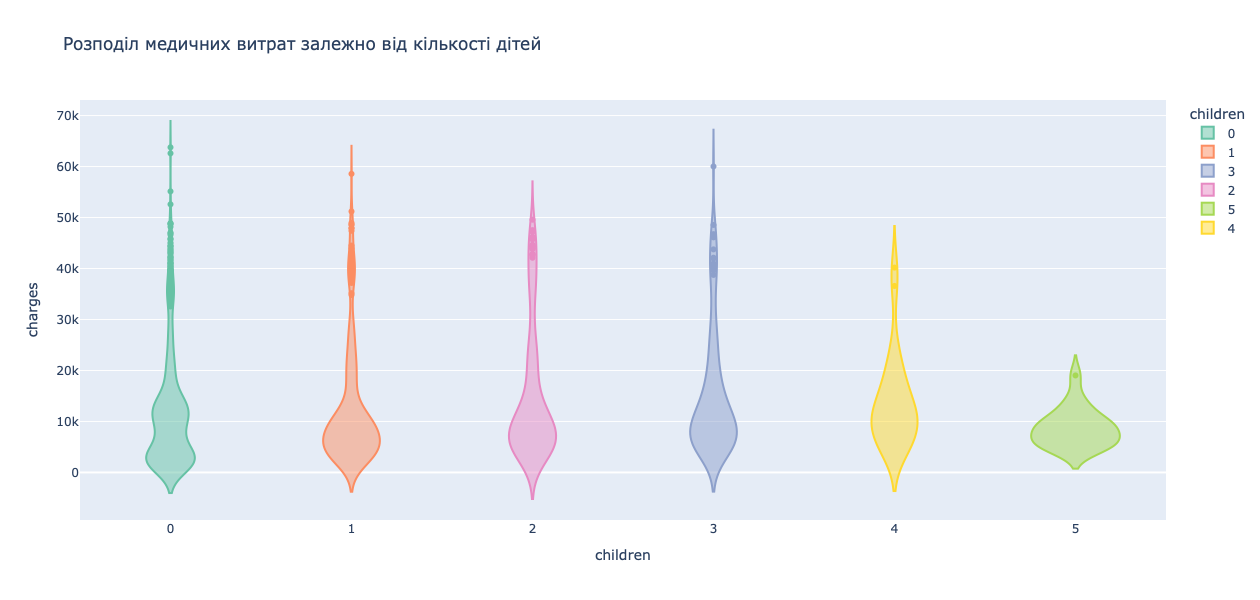

In [46]:
fig = px.violin(medical_df,
                x='children',
                y='charges',
                color='children',
                title='Розподіл медичних витрат залежно від кількості дітей',
                color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(width=900, height=600)
fig.show()

Усі групи мають схожі медіани витрат, це свідчить, що наявність дітей сама по собі не впливає суттєво на ціну страхування.
Група з 0 дітей є найваріативнішою, тому що маємо найбільшу кількість даних там. Група де 5 дітей навпаки має найменшу кількість даних. Групи від 0 до 4 дітей вають викиди, коли ціна за страхування більше ніж 40 тис. 

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [47]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [48]:
def estimate_charges(age, w, b):
    return w * age + b

In [50]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    plt.show();

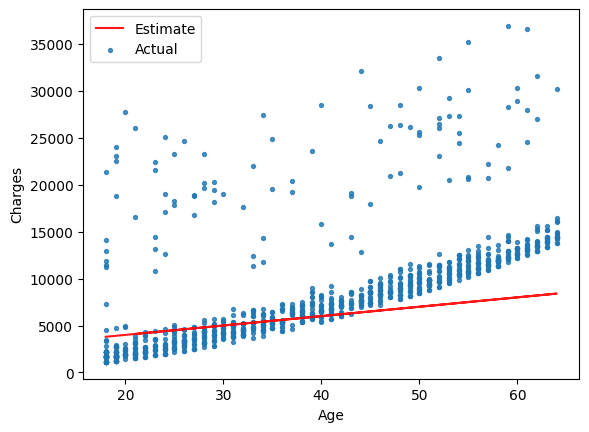

In [54]:
try_parameters(non_smoker_df, 100, 2000)

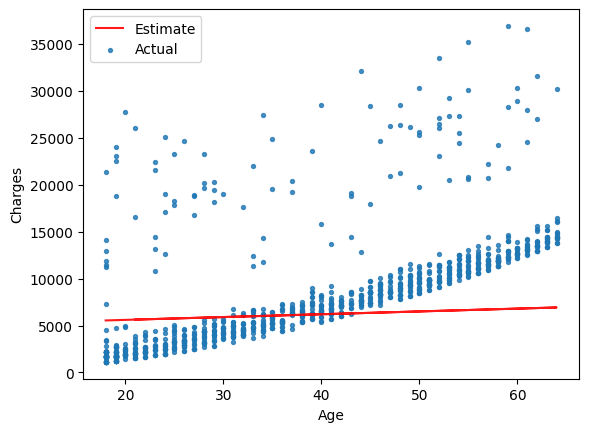

In [55]:
try_parameters(non_smoker_df, 30, 5000)

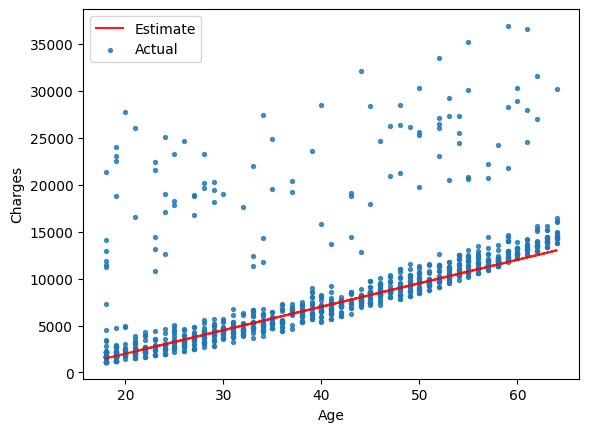

In [67]:
try_parameters(non_smoker_df, 250, -3000)

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [71]:
import numpy as np
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [72]:
ages = non_smoker_df.age.values
actual_charges = non_smoker_df.charges.values

params = [
    (100, 2000),
    (30, 5000),
    (250, -3000)
]

for w, b in params:
    preds = w * ages + b
    error = rmse(actual_charges, preds)
    print(f"w={w}, b={b} -> RMSE: {error:.2f}")

w=100, b=2000 -> RMSE: 5788.83
w=30, b=5000 -> RMSE: 6161.76
w=250, b=-3000 -> RMSE: 4931.48


Не впевнена, що це є правильно, але вирішила спробувати від'ємне число - і воно дало найкращий результат.

Можна побачити, що нахил лінії доволі великий, що показує сильні зміни ціни на страхування зі збільшенням віку людини.

Для мене найкращою стратегією було спочатку знайти потрібний нахил лінії, а потім поступово опускати лінію. Також дуже допомагає використання візуалізацій та результатів RMSE.